# HOMEWORK 2

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW2

In [ ]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "numpy",
#     "matplotlib",
#     "opencv-python",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [ ]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input images
# hm_version = 2
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone images
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"



For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
# Load data

import cv2
import apps.reporter as rpt
from pathlib import Path

# Input data
file_name = "resources/images/sea.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(756, 1008, 3)"


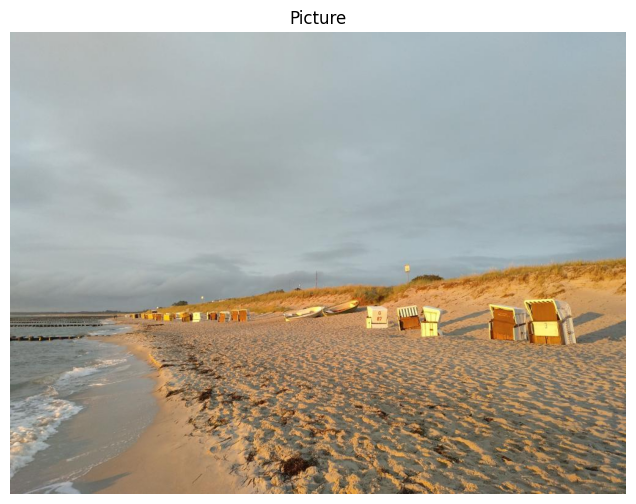

In [2]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Picture")
plt.show()


### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

In [7]:
# White patch

import cv2
import numpy as np

# Input data
row, col = 485, 864
white = img_rgb[row, col, :]

# Solution
if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')
else:
    # Define white patch and the coefficients
    coeffs = 255.0 / white

    # Apply white balancing and generate balanced image
    balanced_wp = np.zeros_like(img_rgb, dtype=np.float32)
    for channel in range(3):
        balanced_wp[..., channel] = img_rgb[..., channel] * coeffs[channel]

    # White patching does not guarantee that the dynamic range is preserved, images must be clipped.
    # Variant 1
    # balanced = balanced / 255
    # balanced[balanced > 1] = 1
    # Variant 2
    balanced_wp = np.clip(balanced_wp, 0, 255).astype(np.uint8)

# Print results


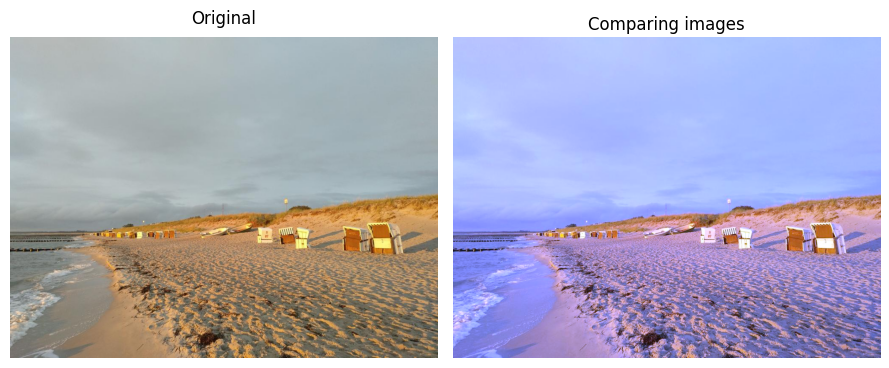

In [9]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_1 = img_rgb
data_2 = balanced_wp

# Solution
_, axes = plt.subplots(1, 2, figsize=(9, 6))

ax = axes[0]
ax.imshow(data_1)
ax.axis(False)
ax.set_title("Original", pad=10, loc='center', color='black')

ax = axes[1]
ax.imshow(data_2)
ax.axis(False)
ax.set_title("White patch", pad=10, loc='center', color='black')

# Plot
plt.title("Comparing images")
plt.tight_layout()
plt.show()


### Gray world
This algorithm assumes that a scene, on average, is gray.

In [ ]:
# Load your image
img = cv2.imread('...')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r =
mean_g =
mean_b =

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr =
kg =
kb =

# Apply color balancing and generate the balanced image
balanced =

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

In [ ]:
# Load your image
img = cv2.imread('...')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r =
max_g =
max_b =

# Apply scale-by-max balancing and generate the balanced image
balanced =

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)